# Econometric Modeling

### Capital Analysis of Vietnam's Listed Manufacturing Enterprises

**Study period:** 2015–2023


## Purpose

This notebook presents the econometric analysis used to examine the relationship between capital-related financial indicators and financial performance.

The analysis estimates Pooled OLS, Fixed Effects Model (FEM), and Random Effects Model (REM), followed by model selection, diagnostic testing, and Generalized Least Squares (GLS) estimation.

## 1. Import Libraries and Data Preparation

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

## 2. Panel Data Preparation

In [ ]:
df = pd.read_csv("../data/data_2015_2023.csv")

In [ ]:
# Bỏ dòng 433 vì có giá trị inf trong cột D/E
df[df.index == 433]
df.drop(433, inplace = True)

In [ ]:
# Chuyển dữ liệu về dạng numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Tìm dòng có giá trị inf
inf_rows = df_numeric[df_numeric.applymap(np.isinf).any(axis=1)]

inf_rows

,Mã,Ngày niêm yết,Year,Phân ngành - ICB L1,7. Chi phí tài chính,1. Vốn và các quỹ,1.2. Thặng dư vốn cổ phần,EPS cơ bản,P/E cơ bản,P/B,...,"Tăng trưởng tổng tài sản (YoY) (Quý, Năm)",8. Chi phí lãi vay (GT),D/E,D/A,Hệ số thanh toán ngắn hạn,Hệ số thanh toán nhanh,Hệ số sử dụng vốn cố định,ROS,Khả năng thanh toán hiện hành,NaN_count
725,NaN,NaN,2016,NaN,-1.178262e+08,2.002854e+10,0.000000e+00,NaN,NaN,NaN,...,0.0000,1.616617e+07,0.310552,0.236963,4.167375,NaN,inf,0.004471,4.220076,8
839,NaN,NaN,2016,NaN,-9.062553e+06,6.046427e+10,0.000000e+00,NaN,NaN,NaN,...,0.0000,NaN,0.315698,0.239947,0.742682,NaN,0.0,inf,4.167589,9
944,NaN,NaN,2016,NaN,-1.936140e+08,6.557335e+09,0.000000e+00,-1451.56,-1.38,0.60,...,1.4988,1.936140e+08,4.338149,0.812669,0.866050,NaN,inf,-0.408862,1.230513,2
1007,NaN,NaN,2016,NaN,-2.117594e+08,8.039605e+09,0.000000e+00,-2973.51,-0.34,1.00,...,-0.7562,1.485154e+07,1.083021,0.519928,1.919589,1.262171,inf,-2.711455,1.923343,0
1372,NaN,NaN,2017,NaN,0.000000e+00,2.425461e+10,0.000000e+00,2021.22,7.32,0.94,...,0.0081,0.000000e+00,0.120680,0.107685,7.141050,NaN,inf,0.681836,9.286345,2
1534,NaN,NaN,2017,NaN,-5.957600e+04,-4.233281e+09,0.000000e+00,-1529.70,-0.59,0.00,...,-0.9697,0.000000e+00,-1.119776,9.348930,0.106964,NaN,inf,-6.435305,0.106964,2
1900,NaN,NaN,2018,NaN,-2.312206e+10,-4.723288e+10,0.000000e+00,-3434.76,-0.09,0.07,...,-0.0989,NaN,-5.320388,1.231461,0.655293,0.370522,0.0,-inf,0.812044,1
1908,NaN,NaN,2018,NaN,0.000000e+00,2.976989e+10,0.000000e+00,1514.95,12.87,1.32,...,0.2021,0.000000e+00,0.097606,0.088926,4.978024,NaN,inf,0.888738,11.245284,2
1932,NaN,NaN,2018,NaN,-2.083909e+09,5.679095e+10,-1.063636e+08,-440.57,-1.82,0.07,...,-0.1386,NaN,0.194056,0.162519,3.704822,3.606257,inf,-0.549612,6.153139,1
2439,NaN,NaN,2019,NaN,-1.681888e+10,-1.016827e+11,0.000000e+00,0.00,0.00,0.00,...,-0.4708,NaN,-2.061978,1.941639,0.464850,NaN,0.0,-inf,0.515029,3


In [ ]:
# Tìm cột có giá trị inf
inf_columns = df.select_dtypes(include=[np.number]).apply(np.isinf).any(axis=0)

print("Các cột có giá trị 'inf':")
print(inf_columns[inf_columns == True].index.tolist())

Các cột có giá trị 'inf':
['Hệ số sử dụng vốn cố định', 'ROS']


In [ ]:
df = df[(df['Phân ngành - ICB L1'] == 'Hàng Tiêu dùng') | (df['Phân ngành - ICB L1'] == 'Công nghiệp') | (df['Phân ngành - ICB L1'] == 'Nguyên vật liệu')]

In [ ]:
mapping = {
    'Hàng Tiêu dùng': 1,
    'Công nghiệp': 2,
    'Nguyên vật liệu': 3
    # 'Dược phẩm và Y tế': 4,
    # 'Dịch vụ Tiêu dùng': 5,
    # 'Công nghệ Thông tin': 6,
    # 'Tài chính': 7,
    # 'Dầu khí': 8,
    # 'Tiện ích Cộng đồng': 9
}

df['Phân ngành - ICB L1 (Số hóa)'] = df['Phân ngành - ICB L1'].map(mapping)

In [ ]:
df = df.sort_values(by=['Mã', 'Year'])

In [ ]:
df['Tăng trưởng nguồn vốn'] =  df.groupby('Mã')['B. TỔNG CỘNG NGUỒN VỐN'].pct_change()
# df['Tăng trưởng nợ phải trả'] =  df.groupby('Mã')['I. NỢ PHẢI TRẢ'].pct_change()
df['Tăng trưởng VCSH'] =  df.groupby('Mã')['II. VỐN CHỦ SỞ HỮU'].pct_change()

In [ ]:
df['Tỷ lệ nợ ngắn hạn'] = df['1. Nợ ngắn hạn'] / df['A. TỔNG CỘNG TÀI SẢN']
df['Tỷ lệ nợ dài hạn'] = df['2. Nợ dài hạn'] / df['A. TỔNG CỘNG TÀI SẢN']
df['Quy mô DN'] = np.log(df['A. TỔNG CỘNG TÀI SẢN'])
df['Tài sản cố định trên tổng tài sản'] = df['2. Tài sản cố định'] / df['A. TỔNG CỘNG TÀI SẢN']
df['Chi phí vốn vay'] = df['7.1. Trong đó: Chi phí lãi vay'] / df['I. NỢ PHẢI TRẢ']
# df["Vốn sử dụng"] = df['A. TỔNG CỘNG TÀI SẢN'] - df['1. Nợ ngắn hạn']
# df["ROCE"] = df['EBIT'] / df["Vốn sử dụng"]
df['Vòng quay tài sản'] = df['3. Doanh thu thuần'] / df['A. TỔNG CỘNG TÀI SẢN']
df['CR']=df['I. TÀI SẢN NGẮN HẠN']/df['1. Nợ ngắn hạn']
df['LIQ'] = (df['I. TÀI SẢN NGẮN HẠN'] - df['1. Nợ ngắn hạn']) / df['A. TỔNG CỘNG TÀI SẢN']
# df['LEV'] = df['I. NỢ PHẢI TRẢ']/df['A. TỔNG CỘNG TÀI SẢN']
# df['Lợi nhuận ròng'] = df['18. Lợi nhuận sau thuế thu nhập doanh nghiệp'] + df['17. Chi phí thuế thu nhập doanh nghiệp']
# df['Năng suất vốn'] = df['Lợi nhuận ròng'] / df['B. TỔNG CỘNG NGUỒN VỐN']
# df['Chi phí vốn so với doanh thu'] = ((df['7.1. Trong đó: Chi phí lãi vay'] + df['7. Chi phí tài chính']) / df['3. Doanh thu thuần'])

In [ ]:
# df = df[~np.isinf(df['Chi phí vốn so với doanh thu'])]

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
# số lượng dữ liệu trước khi loại bỏ NaN
print(f"Số lượng trước khi bỏ: {len(df)}")
cols = ['ROA %', 'ROE %', 'D/E', 'Tăng trưởng nguồn vốn', 'Tăng trưởng VCSH', 'Vòng quay tài sản', 'LIQ',
        'Tỷ lệ nợ ngắn hạn', 'Tỷ lệ nợ dài hạn', 'Quy mô DN',
        'Tăng trưởng doanh thu thuần (YoY) (Quý, Năm)']
df.dropna(subset=['D/E', 'ROA %', 'ROE %', 'Tăng trưởng nguồn vốn','Tăng trưởng VCSH', 'Vòng quay tài sản', 'LIQ',
        'Tỷ lệ nợ ngắn hạn', 'Tỷ lệ nợ dài hạn', 'Quy mô DN',
        'Tăng trưởng doanh thu thuần (YoY) (Quý, Năm)'], inplace=True)
df.rename(columns={
    'ROA %': 'ROA',
    'ROE %': 'ROE',
    'Tăng trưởng nguồn vốn': 'CG',
    'Tăng trưởng VCSH': 'EG',
    'Tỷ lệ nợ ngắn hạn': 'STDR',
    'Tỷ lệ nợ dài hạn': 'LTDR',
    'Vòng quay tài sản': 'AT',
#     'Chi phí vốn so với doanh thu': 'CCR',
    'Quy mô DN': 'SIZE',
    'Tăng trưởng doanh thu thuần (YoY) (Quý, Năm)': 'Growth'
}, inplace=True)
cols = ['ROA', 'ROE', 'D/E', 'CG', 'EG', 'AT', 'LIQ',
        'STDR', 'LTDR', 'SIZE', 'Growth']
# số lượng dữ liệu sau khi loại bỏ NaN
print(f"Số lượng sau khi bỏ: {len(df)}")

Số lượng trước khi bỏ: 4187
Số lượng sau khi bỏ: 3691


In [ ]:
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ROA,3691.0,0.033540,0.248582,-9.584400,0.007600,0.039800,0.083900,4.578500
ROE,3691.0,0.095827,1.141204,-39.283700,0.025700,0.096400,0.186600,46.974200
D/E,3691.0,1.931624,31.640266,-519.020611,0.381981,0.849938,1.716343,1689.877509
CG,3691.0,0.061935,0.314793,-0.971967,-0.063407,0.022592,0.131300,6.450338
EG,3691.0,0.173648,7.777497,-70.402970,-0.013421,0.030777,0.113851,462.991563
AT,3691.0,1.308235,1.102389,-0.001129,0.686073,1.121187,1.653037,13.915240
LIQ,3691.0,-0.079957,3.089094,-104.153469,0.012859,0.165091,0.350272,0.948994
STDR,3691.0,0.679977,3.069498,0.000682,0.263303,0.414371,0.578450,104.544638
LTDR,3691.0,0.087679,0.295329,0.000000,0.000699,0.019028,0.095614,7.865449
SIZE,3691.0,27.027564,1.621622,20.044110,25.926833,26.892050,28.015198,32.866306


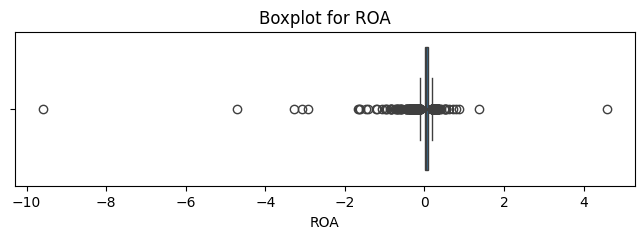

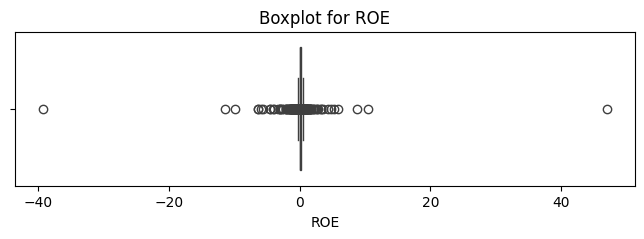

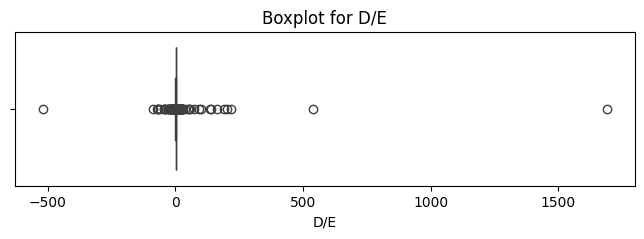

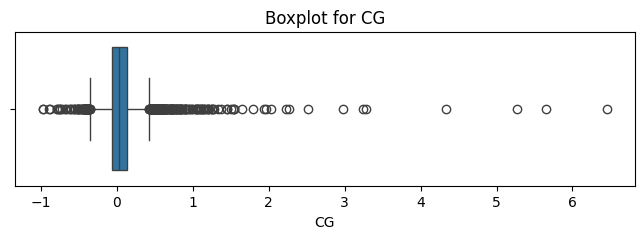

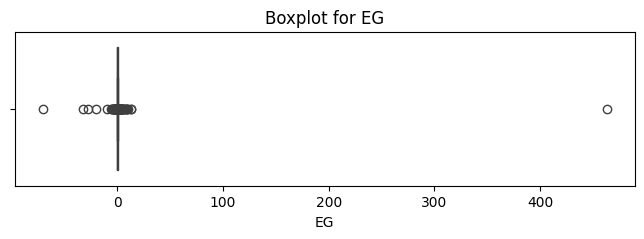

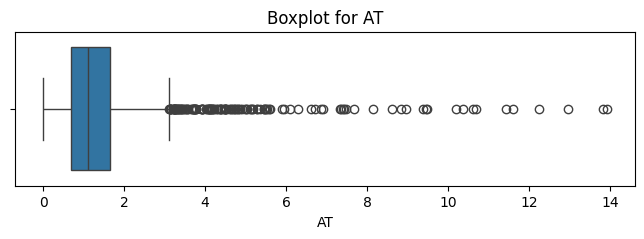

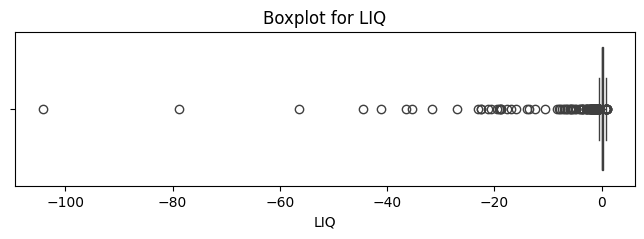

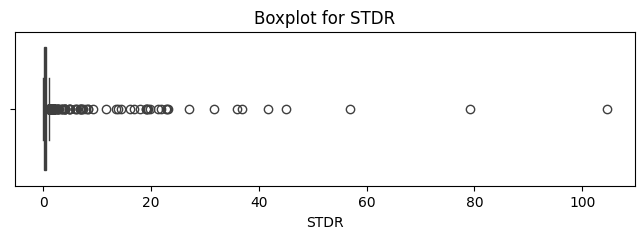

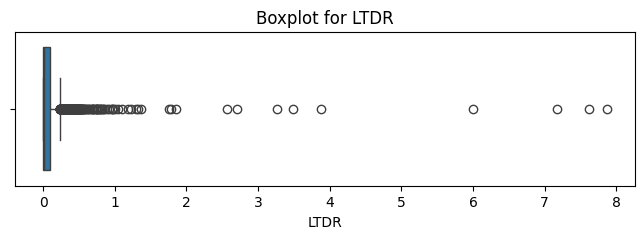

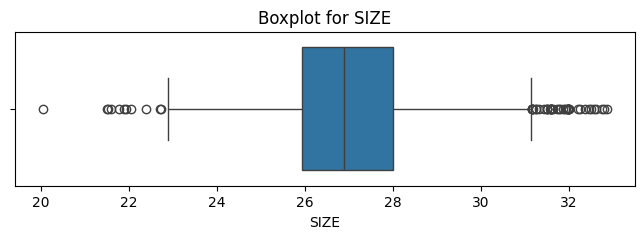

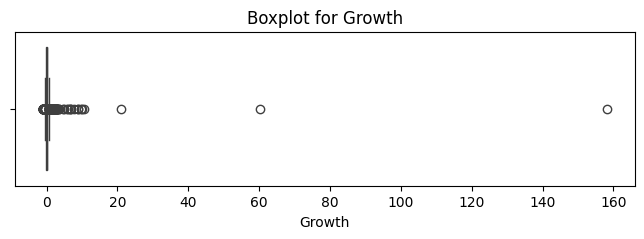

In [ ]:
for col in cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot for {col}')
    plt.show()

In [ ]:
# Loại bỏ outliers bằng cách dữ lại 90% số liệu bằng IQR
print('90% dữ liệu:', 0.9 * len(df))

90% dữ liệu: 3321.9


In [ ]:
desired_count = 3321
k = 1.5

while k <= 5:
    filtered_data = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR

        filtered_data = filtered_data[
            (filtered_data[col] >= lower_bound) &
            (filtered_data[col] <= upper_bound)
        ]

    if len(filtered_data) >= desired_count:
        break

    k += 0.1

print(f"Ngưỡng k tối ưu: {k}")
print(f"Số lượng quan sát còn lại: {len(filtered_data)}")

Ngưỡng k tối ưu: 5.099999999999998
Số lượng quan sát còn lại: 3283


In [ ]:
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 5.099999999999998 * IQR
        upper_bound = Q3 + 5.099999999999998 * IQR
        # Lọc giá trị nằm trong ngưỡng
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Loại bỏ ngoại lai bằng cách giữ lại 90% số liệu bằng IQR
df = remove_outliers_iqr(df, cols)

print(f"Số lượng sau khi bỏ: {len(df)}")

Số lượng sau khi bỏ: 3274


## 3. Variable Selection

In [ ]:
cols_RC = ['ROA', 'ROE', 'D/E', 'CG', 'EG',
        'STDR', 'LTDR', 'SIZE', 'Growth']
# cols_US = ['ROA', 'ROE', 'ROCE', 'AT', 'D/E',
#           'SIZE', 'Growth']
cols_US = ['ROA', 'ROE', 'AT', 'D/E','LIQ',
          'SIZE', 'Growth']

In [ ]:
# Chuẩn hóa dữ liệu
# scaler = StandardScaler()

# # df[cols] = df[cols].replace([np.inf, -np.inf], np.nan)
# # df.dropna(subset=cols, inplace=True)

# df[cols] = scaler.fit_transform(df[cols])

# scaler = RobustScaler()
# # df_robust = df.copy()
# df[cols] = scaler.fit_transform(df[cols])

## 4. Model Specification

### Huy động vốn

In [ ]:
df[cols_RC].describe().T

,count,mean,std,min,25%,50%,75%,max
ROA,3274.0,0.052921,0.074919,-0.366400,0.012100,0.043500,0.087175,0.406700
ROE,3274.0,0.104516,0.146152,-0.779400,0.028800,0.097800,0.183275,0.778600
D/E,3274.0,1.219263,1.277841,-5.792608,0.425207,0.874917,1.673436,7.828883
CG,3274.0,0.044474,0.180267,-0.748568,-0.058144,0.024370,0.124429,1.085772
EG,3274.0,0.051540,0.155363,-0.601483,-0.011500,0.028881,0.101025,0.721151
STDR,3274.0,0.406986,0.213183,0.003076,0.257346,0.399898,0.551407,2.034262
LTDR,3274.0,0.063604,0.095578,0.000000,0.000792,0.018229,0.088131,0.542720
SIZE,3274.0,27.105982,1.590096,22.908135,25.957668,26.948878,28.063928,32.866306
Growth,3274.0,0.029251,0.286573,-1.000000,-0.120550,0.017150,0.156350,1.565100


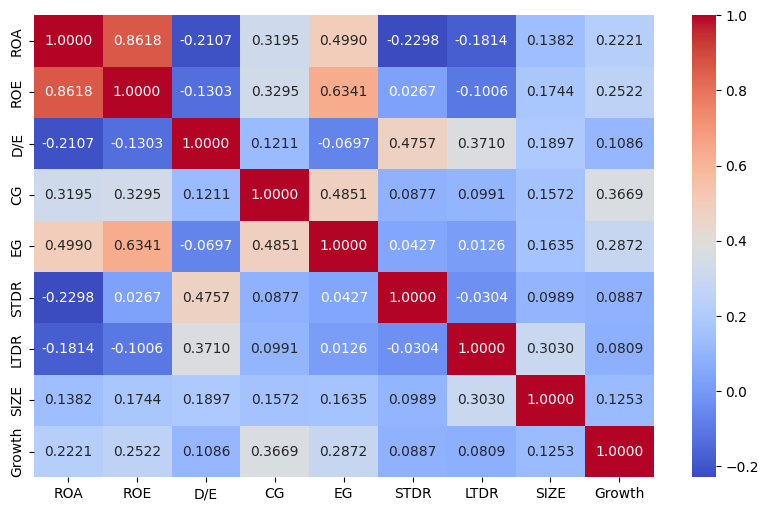

In [ ]:
corr_matrix = df[cols_RC].corr(method='pearson')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f')
# plt.title('Tương quan giữa các biến')
plt.show()

In [ ]:
df = df.set_index(['Mã', 'Year'])

X = df[['D/E', 'CG', 'EG', 'STDR', 'LTDR', 'SIZE', 'Growth']]

### ROA

In [ ]:
y = df['ROA']

In [ ]:
# kiểm định đa cộng tuyến
X_values = X.values

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_values, i) for i in range(X_values.shape[1])]

vif_data

,Variable,VIF
0,D/E,3.156752
1,CG,1.533239
2,EG,1.532060
3,STDR,6.503004
4,LTDR,1.840110
5,SIZE,5.538385
6,Growth,1.199636


In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROA,R-squared:,0.3945
Estimator:,PooledOLS,R-squared (Between):,0.4593
No. Observations:,3274,R-squared (Within):,0.3372
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3945
Time:,20:27:45,Log-likelihood,4660.2
Cov. Estimator:,Unadjusted,,
,,F-statistic:,303.96
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,3266)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,303.96


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.3685
Estimator:,RandomEffects,R-squared (Between):,0.4261
No. Observations:,3274,R-squared (Within):,0.3657
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3786
Time:,20:27:46,Log-likelihood,6020.8
Cov. Estimator:,Clustered,,
,,F-statistic:,272.28
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,3266)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,87.063


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.3656
Estimator:,PanelOLS,R-squared (Between):,0.4102
No. Observations:,3274,R-squared (Within):,0.3634
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3717
Time:,20:27:46,Log-likelihood,6381.4
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,229.68
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,2790)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,2607.7


In [ ]:
comparison = compare({'PooledOLS': pooled_res, 'RandomEffects': REM_res, 'FixedEffects': FEM_res}, stars=True)
comparison.summary

,PooledOLS,RandomEffects,FixedEffects
Dep. Variable,ROA,ROA,ROA
Estimator,PooledOLS,RandomEffects,PanelOLS
No. Observations,3274,3274,3274
Cov. Est.,Unadjusted,Clustered,Driscoll-Kraay
R-squared,0.3945,0.3685,0.3656
R-Squared (Within),0.3372,0.3657,0.3634
R-Squared (Between),0.4593,0.4261,0.4102
R-Squared (Overall),0.3945,0.3786,0.3717
F-statistic,303.96,272.28,229.68
P-value (F-stat),0.0000,0.0000,0.0000


In [ ]:
def f_test(pooled_res, FEM_res):
    # RSS của Pooled OLS
    rss_pooled = np.sum(pooled_res.resids**2)

    # RSS của Fixed Effects
    rss_fem = np.sum(FEM_res.resids**2)

    # Số thực thể và số quan sát
    num_entities = len(df.index.get_level_values('Mã').unique())
    n_obs = len(y)
    k = num_entities - 1

    # F-statistic
    f_stat = ((rss_pooled - rss_fem) / k) / (rss_fem / (n_obs - k))
    p_value = 1 - stats.f.cdf(f_stat, dfn=k, dfd=n_obs - k)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_value}")
    if (p_value < 0.05):
        print('The Fixed Effects model is preferred')
    else:
        print('The Pooled OLS model is preferred')

f_test(pooled_res, FEM_res)

F-statistic: 11.134865117699567
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
# Dùng kiểm định hausman để chọn giữa mô hình FEM và REM
def hausman_test(FEM_res, REM_res):
    b_fe = FEM_res.params
    b_re = REM_res.params
    diff = b_fe - b_re

    V_fe = FEM_res.cov
    V_re = REM_res.cov
    V_diff = V_fe - V_re

    hausman_stat = diff.T @ np.linalg.inv(V_diff) @ diff
    p_value = stats.chi2.sf(hausman_stat, df=len(diff))

    print(f"Hausman Test Statistic: {hausman_stat}")
    print(f"P-value: {p_value}")

    if (p_value > 0.05):
        print('The Random Effects model is preferred.')
    else:
        print('The Fixed Effects model is preferred')

hausman_test(FEM_res, REM_res)

Hausman Test Statistic: 9.806262199757509
P-value: 0.27888800542836145
The Random Effects model is preferred.


In [ ]:
# Kiểm định phụ thuốc chéo
def pesaran_cd_test(data):

    if isinstance(data, pd.DataFrame):
        data = data.values

    n, T = data.shape

    corr_matrix = np.corrcoef(data, rowvar=False)

    num_pairs = n * (n - 1) / 2

    avg_corr = np.sum(corr_matrix) / (n * (n - 1))

    test_statistic = np.sqrt(T) * avg_corr

    z = test_statistic / np.sqrt(2 / (n * (n - 1)))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))

    return test_statistic, p_value

# Pesaran CD test
test_statistic, p_value = pesaran_cd_test(df[['ROA', 'D/E', 'CG', 'EG', 'STDR', 'LTDR', 'SIZE', 'Growth']])
print(f'Test Statistic: {test_statistic}, P-value: {p_value}')

Test Statistic: 4.287378822395863e-06, P-value: 0.9920818790092889


p value > 0.05 => không có hiện tượng phụ thuộc chéo

In [ ]:
residuals = REM_res.resids.values

# X = REM_res.model.exog.dataframe.values
# X = X.dataframe.values
# Thực hiện kiểm định Breusch-Pagan
bp_test = het_breuschpagan(residuals, REM_res.model.exog.dataframe.values)

labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
result = dict(zip(labels, bp_test))
print("Kết quả kiểm định Breusch-Pagan: \n", result)

Kết quả kiểm định Breusch-Pagan: 
 {'LM Statistic': 62.738288205981945, 'LM Test p-value': 4.276514903880119e-11, 'F-Statistic': 9.11538684215115, 'F-Test p-value': 3.391381594660566e-11}


p value < 0.05 => có hiện tượng phương sai sai số thay đổi

In [ ]:
# Thực hiện kiểm định tự tương quan với pp Wooldridge
residuals = REM_res.resids

n = df.index.get_level_values(0).nunique()
t = len(df) / n
SSR = np.sum(residuals**2)
F_stat = (SSR / (t - 1)) / ((np.var(residuals) / t))
p_value = 1 - stats.f.cdf(F_stat, t - 1, (n - 1) * (t - 1))

print(f"Thống kê F: {F_stat}")
print(f"P-value: {p_value}")


Thống kê F: 3823.2081144149683
P-value: 1.1102230246251565e-16


p value < 0.05 => có hiện tượng tự tương quan

Sử dụng mô hình FGLS để khắc phục 2 khuyết tật

In [ ]:
# Lấy phần dư (residuals) từ mô hình REM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.393
Model:                            GLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     302.7
Date:                Tue, 06 May 2025   Prob (F-statistic):               0.00
Time:                        20:27:49   Log-Likelihood:                 4675.5
No. Observations:                3274   AIC:                            -9335.
Df Residuals:                    3266   BIC:                            -9286.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0867      0.018     -4.767      0.000      -0.122      -0.051
D/E         4.134e-05      0.001      0.041      0.968      -0.002       0.002
CG             0.0461      0.007      6.847      0.000       0.033       0.059
EG             0.1977      0.008     25.582      0.000       0.183       0.213
STDR          -0.1017      0.006    -18.024      0.000      -0.113      -0.091
LTDR          -0.1990      0.012    -16.321      0.000      -0.223      -0.175
SIZE           0.0067      0.001      9.746      0.000       0.005       0.008
Growth         0.0230      0.004      5.983      0.000       0.015       0.031
==============================================================================
Omnibus:                      224.539   Durbin-Watson:                   0.877
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1055.402
Skew:                           0.107   Prob(JB):                    6.64e-230
Kurtosis:                       5.773   Cond. No.                         498.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:

from statsmodels.robust.robust_linear_model import RLM

# Thêm hằng số vào ma trận X
# X = sm.add_constant(X)

# Robust Linear Model
robust_model = RLM(y, X)
robust_results = robust_model.fit()

robust_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                    ROA   No. Observations:                 3274
Model:                            RLM   Df Residuals:                     3266
Method:                          IRLS   Df Model:                            7
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 06 May 2025                                         
Time:                        20:27:49                                         
No. Iterations:                    32                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0522      0.015     -3.443      0.001      -0.082      -0.022
D/E            0.0008      0.001      0.919      0.358      -0.001       0.002
CG             0.0380      0.006      6.759      0.000       0.027       0.049
EG             0.2228      0.006     34.776      0.000       0.210       0.235
STDR          -0.0970      0.005    -20.724      0.000      -0.106      -0.088
LTDR          -0.1760      0.010    -17.271      0.000      -0.196      -0.156
SIZE           0.0052      0.001      9.048      0.000       0.004       0.006
Growth         0.0212      0.003      6.609      0.000       0.015       0.027
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [ ]:
# from statsmodels.sandbox.regression import gmm

# from linearmodels.iv import IV2SLS

# # Biến phụ thuộc
# Y = df["ROA %"]

# # Biến độc lập (nghi ngờ nội sinh)
# X = df["Tỷ lệ nợ ngắn hạn"]

# # Biến công cụ
# Z = df['Chi phí vốn vay']

# # Biến kiểm soát
# W = df[['Quy mô DN',
#          'Tăng trưởng doanh thu thuần (YoY) (Quý, Năm)']]

# # Hồi quy OLS (bước đầu để so sánh)
# ols_model = IV2SLS(dependent=Y, exog=pd.DataFrame(W), endog=pd.DataFrame(X), instruments=pd.DataFrame(Z))
# ols_results = ols_model.fit()
# print("OLS Results:\n", ols_results.summary)

# # Hồi quy IV (2SLS)
# iv_model = IV2SLS(dependent=Y, exog=pd.DataFrame(W), endog=pd.DataFrame(X), instruments=pd.DataFrame(Z))
# iv_results = iv_model.fit()
# print("\nIV Results (2SLS):\n", iv_results.summary)

# # Kiểm định Durbin-Wu-Hausman
# residuals = iv_results.resids
# residuals_ols = ols_results.resids
# test_stat = len(residuals) * (residuals - residuals_ols).var() / residuals.var()
# p_value = 1 - stats.chi2.cdf(test_stat, df=1)  # df=1 vì so sánh 2 mô hình
# print("\nDurbin-Wu-Hausman Test:")
# print(f"Test statistic: {test_stat}, P-value: {p_value}")

In [ ]:
# residuals = fgls_results.resid

# # Thực hiện kiểm định Wooldridge
# n = df.index.get_level_values(0).nunique()  # Số nhóm (công ty)
# t = len(df) / n                             # Số thời kỳ trung bình
# SSR = np.sum(residuals**2)
# F_stat = (SSR / (t - 1)) / ((np.var(residuals) / t))
# p_value = 1 - stats.f.cdf(F_stat, t - 1, (n - 1) * (t - 1))

# print(f"Thống kê F: {F_stat}")
# print(f"P-value: {p_value}")

### ROE

In [ ]:
y = df['ROE']

In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROE,R-squared:,0.4373
Estimator:,PooledOLS,R-squared (Between):,0.4561
No. Observations:,3274,R-squared (Within):,0.4268
Date:,"Tue, May 06 2025",R-squared (Overall):,0.4373
Time:,20:27:49,Log-likelihood,2592.3
Cov. Estimator:,Unadjusted,,
,,F-statistic:,362.52
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,3266)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,362.52


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.4444
Estimator:,RandomEffects,R-squared (Between):,0.3991
No. Observations:,3274,R-squared (Within):,0.4552
Date:,"Tue, May 06 2025",R-squared (Overall):,0.4197
Time:,20:27:50,Log-likelihood,3688.6
Cov. Estimator:,Clustered,,
,,F-statistic:,373.16
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,3266)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,74.876


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROE,R-squared:,0.4525
Estimator:,PanelOLS,R-squared (Between):,0.3296
No. Observations:,3274,R-squared (Within):,0.4556
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3983
Time:,20:27:50,Log-likelihood,4097.4
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,329.39
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(7,2790)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,3144.7


In [ ]:
comparison = compare({'PooledOLS': pooled_res, 'RandomEffects': REM_res, 'FixedEffects': FEM_res}, stars=True)
comparison.summary

,PooledOLS,RandomEffects,FixedEffects
Dep. Variable,ROE,ROE,ROE
Estimator,PooledOLS,RandomEffects,PanelOLS
No. Observations,3274,3274,3274
Cov. Est.,Unadjusted,Clustered,Driscoll-Kraay
R-squared,0.4373,0.4444,0.4525
R-Squared (Within),0.4268,0.4552,0.4556
R-Squared (Between),0.4561,0.3991,0.3296
R-Squared (Overall),0.4373,0.4197,0.3983
F-statistic,362.52,373.16,329.39
P-value (F-stat),0.0000,0.0000,0.0000


In [ ]:
f_test(pooled_res, FEM_res)

F-statistic: 9.01768643947202
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -15.610417121449512
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
residuals = REM_res.resids.values

# Thực hiện kiểm định Breusch-Pagan
bp_test = het_breuschpagan(residuals, REM_res.model.exog.dataframe.values)

labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
result = dict(zip(labels, bp_test))
print("Kết quả kiểm định Breusch-Pagan: \n", result)

Kết quả kiểm định Breusch-Pagan: 
 {'LM Statistic': 139.1199914677241, 'LM Test p-value': 7.770735740002699e-27, 'F-Statistic': 20.705549490020513, 'F-Test p-value': 2.0097435568928317e-27}


In [ ]:
# Thực hiện kiểm định tự tương quan với pp Wooldridge
residuals = REM_res.resids

n = df.index.get_level_values(0).nunique()
t = len(df) / n
SSR = np.sum(residuals**2)
F_stat = (SSR / (t - 1)) / ((np.var(residuals) / t))
p_value = 1 - stats.f.cdf(F_stat, t - 1, (n - 1) * (t - 1))

print(f"Thống kê F: {F_stat}")
print(f"P-value: {p_value}")

Thống kê F: 3823.4117275303265
P-value: 1.1102230246251565e-16


In [ ]:
# Lấy phần dư (residuals) từ mô hình REM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS (Generalized Least Squares) với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.435
Model:                            GLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     359.0
Date:                Tue, 06 May 2025   Prob (F-statistic):               0.00
Time:                        20:27:52   Log-Likelihood:                 2596.7
No. Observations:                3274   AIC:                            -5177.
Df Residuals:                    3266   BIC:                            -5129.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1882      0.034     -5.469      0.000      -0.256      -0.121
D/E           -0.0102      0.002     -5.269      0.000      -0.014      -0.006
CG             0.0163      0.013      1.277      0.202      -0.009       0.041
EG             0.5411      0.015     37.090      0.000       0.512       0.570
STDR           0.0136      0.011      1.273      0.203      -0.007       0.034
LTDR          -0.1748      0.023     -7.573      0.000      -0.220      -0.130
SIZE           0.0103      0.001      8.011      0.000       0.008       0.013
Growth         0.0409      0.007      5.619      0.000       0.027       0.055
==============================================================================
Omnibus:                      311.432   Durbin-Watson:                   1.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1572.169
Skew:                          -0.312   Prob(JB):                         0.00
Kurtosis:                       6.337   Cond. No.                         499.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Chia 2 giai đoạn

In [ ]:
df_prev_2020 = df[df.index.get_level_values('Year') < 2020]
df_after_2020 = df[df.index.get_level_values('Year') >= 2020]

#### Trước 2020

##### ROA

In [ ]:
X = df_prev_2020[['D/E', 'CG', 'EG', 'STDR', 'LTDR', 'SIZE', 'Growth']]
y = df_prev_2020['ROA']

In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROA,R-squared:,0.3632
Estimator:,PooledOLS,R-squared (Between):,0.3984
No. Observations:,1598,R-squared (Within):,0.2727
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3632
Time:,20:27:53,Log-likelihood,2294.5
Cov. Estimator:,Unadjusted,,
,,F-statistic:,129.57
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(7,1590)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,129.57


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.3282
Estimator:,RandomEffects,R-squared (Between):,0.3743
No. Observations:,1598,R-squared (Within):,0.3195
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3441
Time:,20:27:53,Log-likelihood,3132.0
Cov. Estimator:,Clustered,,
,,F-statistic:,110.98
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(7,1590)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,47.576


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.3212
Estimator:,PanelOLS,R-squared (Between):,0.3028
No. Observations:,1598,R-squared (Within):,0.3274
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2858
Time:,20:27:54,Log-likelihood,3426.0
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,76.912
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(7,1138)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,-9.258e+16


In [ ]:
def f_test(pooled_res, FEM_res):
    # RSS của Pooled OLS
    rss_pooled = np.sum(pooled_res.resids**2)

    # RSS của Fixed Effects
    rss_fem = np.sum(FEM_res.resids**2)

    # Số thực thể và số quan sát
    num_entities = len(df_prev_2020.index.get_level_values('Mã').unique())
    n_obs = len(y)
    k = num_entities - 1

    # F-statistic
    f_stat = ((rss_pooled - rss_fem) / k) / (rss_fem / (n_obs - k))
    p_value = 1 - stats.f.cdf(f_stat, dfn=k, dfd=n_obs - k)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_value}")
    if (p_value < 0.05):
        print('The Fixed Effects model is preferred')
    else:
        print('The Pooled OLS model is preferred')

f_test(pooled_res, FEM_res)

F-statistic: 7.9864333875847535
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
# Dùng kiểm định hausman để chọn giữa mô hình FEM và REM
def hausman_test(FEM_res, REM_res):
    b_fe = FEM_res.params
    b_re = REM_res.params
    diff = b_fe - b_re

    V_fe = FEM_res.cov
    V_re = REM_res.cov
    V_diff = V_fe - V_re

    hausman_stat = diff.T @ np.linalg.inv(V_diff) @ diff
    p_value = stats.chi2.sf(hausman_stat, df=len(diff))

    print(f"Hausman Test Statistic: {hausman_stat}")
    print(f"P-value: {p_value}")

    if (p_value > 0.05):
        print('The Random Effects model is preferred.')
    else:
        print('The Fixed Effects model is preferred')

hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -19.136235210527836
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_prev_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.353
Model:                            GLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     123.9
Date:                Tue, 06 May 2025   Prob (F-statistic):          2.03e-145
Time:                        20:27:54   Log-Likelihood:                 2319.2
No. Observations:                1598   AIC:                            -4622.
Df Residuals:                    1590   BIC:                            -4579.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0487      0.026     -1.873      0.061      -0.100       0.002
D/E           -0.0009      0.001     -0.650      0.516      -0.004       0.002
CG             0.0506      0.009      5.796      0.000       0.033       0.068
EG             0.1607      0.010     15.509      0.000       0.140       0.181
STDR          -0.1025      0.008    -12.374      0.000      -0.119      -0.086
LTDR          -0.1980      0.016    -12.391      0.000      -0.229      -0.167
SIZE           0.0056      0.001      5.752      0.000       0.004       0.008
Growth         0.0192      0.006      3.352      0.001       0.008       0.030
==============================================================================
Omnibus:                       91.104   Durbin-Watson:                   1.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              280.772
Skew:                           0.228   Prob(JB):                     1.07e-61
Kurtosis:                       5.002   Cond. No.                         511.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### ROE

In [ ]:
y = df_prev_2020['ROE']

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.3566
Estimator:,RandomEffects,R-squared (Between):,0.3557
No. Observations:,1598,R-squared (Within):,0.3625
Date:,"Tue, May 06 2025",R-squared (Overall):,0.3462
Time:,20:27:55,Log-likelihood,2014.0
Cov. Estimator:,Clustered,,
,,F-statistic:,125.87
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(7,1590)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,32.932


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROE,R-squared:,0.3618
Estimator:,PanelOLS,R-squared (Between):,0.2877
No. Observations:,1598,R-squared (Within):,0.3713
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2977
Time:,20:27:55,Log-likelihood,2325.1
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,92.175
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(7,1138)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,-2.867e+15


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -23.47816370818283
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_prev_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.362
Model:                            GLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     128.8
Date:                Tue, 06 May 2025   Prob (F-statistic):          3.18e-150
Time:                        20:27:56   Log-Likelihood:                 1269.8
No. Observations:                1598   AIC:                            -2524.
Df Residuals:                    1590   BIC:                            -2481.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1489      0.051     -2.932      0.003      -0.249      -0.049
D/E           -0.0067      0.003     -2.473      0.014      -0.012      -0.001
CG             0.0384      0.017      2.240      0.025       0.005       0.072
EG             0.4501      0.020     22.382      0.000       0.411       0.490
STDR           0.0204      0.016      1.293      0.196      -0.011       0.051
LTDR          -0.1743      0.031     -5.586      0.000      -0.236      -0.113
SIZE           0.0093      0.002      4.887      0.000       0.006       0.013
Growth         0.0369      0.011      3.293      0.001       0.015       0.059
==============================================================================
Omnibus:                       68.742   Durbin-Watson:                   1.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              197.706
Skew:                          -0.128   Prob(JB):                     1.17e-43
Kurtosis:                       4.704   Cond. No.                         513.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Sau 2020

In [ ]:
X = df_after_2020[['D/E', 'CG', 'EG', 'STDR', 'LTDR', 'SIZE', 'Growth']]

##### ROA

In [ ]:
y = df_after_2020['ROA']

In [ ]:
X = sm.add_constant(X)

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.4100
Estimator:,RandomEffects,R-squared (Between):,0.4688
No. Observations:,1676,R-squared (Within):,0.3936
Date:,"Tue, May 06 2025",R-squared (Overall):,0.4213
Time:,20:27:56,Log-likelihood,3248.3
Cov. Estimator:,Clustered,,
,,F-statistic:,165.56
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(7,1668)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,62.471


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.3930
Estimator:,PanelOLS,R-squared (Between):,0.3109
No. Observations:,1676,R-squared (Within):,0.3931
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2836
Time:,20:27:56,Log-likelihood,3566.7
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,112.30
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(7,1214)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,-1.602e+17


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -1.1387672843575636
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_after_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.435
Model:                            GLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     183.5
Date:                Tue, 06 May 2025   Prob (F-statistic):          1.24e-201
Time:                        20:27:57   Log-Likelihood:                 2398.6
No. Observations:                1676   AIC:                            -4781.
Df Residuals:                    1668   BIC:                            -4738.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1391      0.025     -5.571      0.000      -0.188      -0.090
D/E            0.0019      0.001      1.271      0.204      -0.001       0.005
CG             0.0321      0.010      3.174      0.002       0.012       0.052
EG             0.2339      0.011     20.488      0.000       0.211       0.256
STDR          -0.1010      0.008    -12.981      0.000      -0.116      -0.086
LTDR          -0.2111      0.018    -11.456      0.000      -0.247      -0.175
SIZE           0.0083      0.001      8.822      0.000       0.006       0.010
Growth         0.0198      0.005      3.898      0.000       0.010       0.030
==============================================================================
Omnibus:                      128.217   Durbin-Watson:                   0.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              681.364
Skew:                           0.029   Prob(JB):                    1.11e-148
Kurtosis:                       6.123   Cond. No.                         494.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### ROE

In [ ]:
y = df_after_2020['ROE']

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.4769
Estimator:,RandomEffects,R-squared (Between):,0.5500
No. Observations:,1676,R-squared (Within):,0.4514
Date:,"Tue, May 06 2025",R-squared (Overall):,0.4906
Time:,20:27:58,Log-likelihood,1968.6
Cov. Estimator:,Clustered,,
,,F-statistic:,217.24
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(7,1668)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,52.519


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_after_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.506
Model:                            GLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     244.2
Date:                Tue, 06 May 2025   Prob (F-statistic):          3.21e-250
Time:                        20:27:58   Log-Likelihood:                 1381.1
No. Observations:                1676   AIC:                            -2746.
Df Residuals:                    1668   BIC:                            -2703.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2703      0.046     -5.905      0.000      -0.360      -0.181
D/E           -0.0131      0.003     -4.776      0.000      -0.019      -0.008
CG            -0.0106      0.019     -0.572      0.567      -0.047       0.026
EG             0.6142      0.021     29.302      0.000       0.573       0.655
STDR           0.0091      0.014      0.639      0.523      -0.019       0.037
LTDR          -0.2010      0.034     -5.939      0.000      -0.267      -0.135
SIZE           0.0131      0.002      7.605      0.000       0.010       0.016
Growth         0.0350      0.009      3.748      0.000       0.017       0.053
==============================================================================
Omnibus:                      224.758   Durbin-Watson:                   1.279
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1623.353
Skew:                          -0.393   Prob(JB):                         0.00
Kurtosis:                       7.757   Cond. No.                         494.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Sử dụng vốn

In [ ]:
df[cols_US].describe().T

,count,mean,std,min,25%,50%,75%,max
ROA,3274.0,0.052921,0.074919,-0.366400,0.012100,0.043500,0.087175,0.406700
ROE,3274.0,0.104516,0.146152,-0.779400,0.028800,0.097800,0.183275,0.778600
AT,3274.0,1.284830,0.840899,-0.001129,0.731639,1.143718,1.666073,6.286853
D/E,3274.0,1.219263,1.277841,-5.792608,0.425207,0.874917,1.673436,7.828883
LIQ,3274.0,0.201052,0.266608,-1.575942,0.044343,0.183533,0.360516,0.948994
SIZE,3274.0,27.105982,1.590096,22.908135,25.957668,26.948878,28.063928,32.866306
Growth,3274.0,0.029251,0.286573,-1.000000,-0.120550,0.017150,0.156350,1.565100


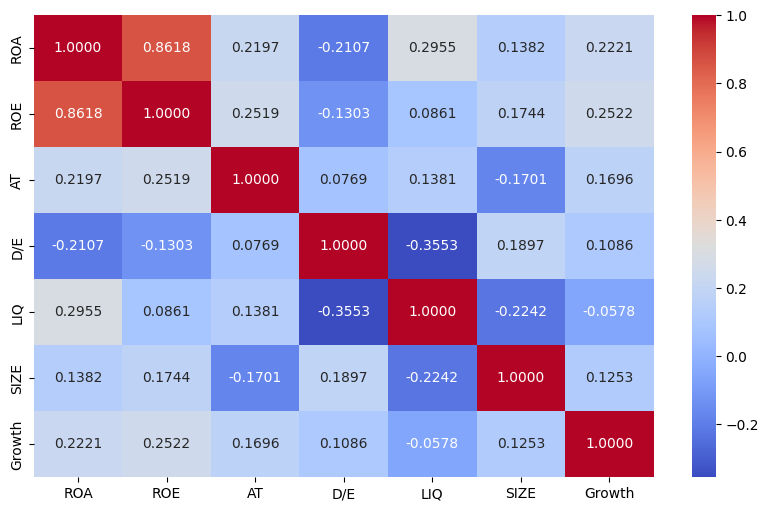

In [ ]:
corr_matrix = df[cols_US].corr(method='pearson')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f')
# plt.title('Tương quan giữa các biến')
plt.show()

In [ ]:
X = df[['AT', 'D/E','LIQ', 'SIZE', 'Growth']]

## ROA

In [ ]:
y = df['ROA']

In [ ]:
# kiểm định đa cộng tuyến
X_values = X.values

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_values, i) for i in range(X_values.shape[1])]

vif_data

,Variable,VIF
0,AT,3.457610
1,D/E,2.268779
2,LIQ,1.829493
3,SIZE,4.743610
4,Growth,1.050133


In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROA,R-squared:,0.2424
Estimator:,PooledOLS,R-squared (Between):,0.3204
No. Observations:,3274,R-squared (Within):,0.1437
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2424
Time:,20:28:01,Log-likelihood,4293.3
Cov. Estimator:,Unadjusted,,
,,F-statistic:,209.10
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,3268)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,209.10


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.1687
Estimator:,RandomEffects,R-squared (Between):,0.3203
No. Observations:,3274,R-squared (Within):,0.1473
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2395
Time:,20:28:02,Log-likelihood,5553.0
Cov. Estimator:,Clustered,,
,,F-statistic:,132.65
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,3268)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,69.144


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.1702
Estimator:,PanelOLS,R-squared (Between):,0.2644
No. Observations:,3274,R-squared (Within):,0.1376
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2034
Time:,20:28:02,Log-likelihood,5941.9
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,114.56
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,2792)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,1270.3


In [ ]:
comparison = compare({'PooledOLS': pooled_res, 'RandomEffects': REM_res, 'FixedEffects': FEM_res}, stars=True)
comparison.summary

,PooledOLS,RandomEffects,FixedEffects
Dep. Variable,ROA,ROA,ROA
Estimator,PooledOLS,RandomEffects,PanelOLS
No. Observations,3274,3274,3274
Cov. Est.,Unadjusted,Clustered,Driscoll-Kraay
R-squared,0.2424,0.1687,0.1702
R-Squared (Within),0.1437,0.1473,0.1376
R-Squared (Between),0.3204,0.3203,0.2644
R-Squared (Overall),0.2424,0.2395,0.2034
F-statistic,209.10,132.65,114.56
P-value (F-stat),0.0000,0.0000,0.0000


In [ ]:
def f_test(pooled_res, FEM_res):
    # RSS của Pooled OLS
    rss_pooled = np.sum(pooled_res.resids**2)

    # RSS của Fixed Effects
    rss_fem = np.sum(FEM_res.resids**2)

    # Số thực thể và số quan sát
    num_entities = len(df.index.get_level_values('Mã').unique())
    n_obs = len(y)
    k = num_entities - 1

    # F-statistic
    f_stat = ((rss_pooled - rss_fem) / k) / (rss_fem / (n_obs - k))
    p_value = 1 - stats.f.cdf(f_stat, dfn=k, dfd=n_obs - k)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_value}")
    if (p_value < 0.05):
        print('The Fixed Effects model is preferred')
    else:
        print('The Pooled OLS model is preferred')

f_test(pooled_res, FEM_res)

F-statistic: 10.392178460563812
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
# Dùng kiểm định hausman để chọn giữa mô hình FEM và REM
def hausman_test(FEM_res, REM_res):
    b_fe = FEM_res.params
    b_re = REM_res.params
    diff = b_fe - b_re

    V_fe = FEM_res.cov
    V_re = REM_res.cov
    V_diff = V_fe - V_re

    hausman_stat = diff.T @ np.linalg.inv(V_diff) @ diff
    p_value = stats.chi2.sf(hausman_stat, df=len(diff))

    print(f"Hausman Test Statistic: {hausman_stat}")
    print(f"P-value: {p_value}")

    if (p_value > 0.05):
        print('The Random Effects model is preferred.')
    else:
        print('The Fixed Effects model is preferred')

hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -4.654867161684336
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Kiểm định phụ thuốc chéo
def pesaran_cd_test(data):

    if isinstance(data, pd.DataFrame):
        data = data.values

    n, T = data.shape

    corr_matrix = np.corrcoef(data, rowvar=False)

    num_pairs = n * (n - 1) / 2

    avg_corr = np.sum(corr_matrix) / (n * (n - 1))

    test_statistic = np.sqrt(T) * avg_corr

    z = test_statistic / np.sqrt(2 / (n * (n - 1)))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))

    return test_statistic, p_value

# Pesaran CD test
test_statistic, p_value = pesaran_cd_test(df[['ROA', 'AT', 'D/E', 'LIQ','SIZE', 'Growth']])
print(f'Test Statistic: {test_statistic}, P-value: {p_value}')

Test Statistic: 1.6757507142912273e-06, P-value: 0.9969051063638525


In [ ]:
residuals = FEM_res.resids.values

# Thực hiện kiểm định Breusch-Pagan
bp_test = het_breuschpagan(residuals, REM_res.model.exog.dataframe.values)

labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
result = dict(zip(labels, bp_test))
print("Kết quả kiểm định Breusch-Pagan: \n", result)

Kết quả kiểm định Breusch-Pagan: 
 {'LM Statistic': 61.67726189855959, 'LM Test p-value': 5.468990367226343e-12, 'F-Statistic': 12.549255371745122, 'F-Test p-value': 4.3039059045437645e-12}


In [ ]:
# Thực hiện kiểm định tự tương quan với pp Wooldridge
residuals = FEM_res.resids

n = df.index.get_level_values(0).nunique()
t = len(df) / n
SSR = np.sum(residuals**2)
F_stat = (SSR / (t - 1)) / ((np.var(residuals) / t))
p_value = 1 - stats.f.cdf(F_stat, t - 1, (n - 1) * (t - 1))

print(f"Thống kê F: {F_stat}")
print(f"P-value: {p_value}")


Thống kê F: 3822.7803138373747
P-value: 1.1102230246251565e-16


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.240
Model:                            GLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     206.9
Date:                Tue, 06 May 2025   Prob (F-statistic):          3.69e-192
Time:                        20:28:04   Log-Likelihood:                 4298.8
No. Observations:                3274   AIC:                            -8586.
Df Residuals:                    3268   BIC:                            -8549.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2841      0.021    -13.534      0.000      -0.325      -0.243
AT             0.0182      0.001     12.780      0.000       0.015       0.021
D/E           -0.0116      0.001    -11.980      0.000      -0.014      -0.010
LIQ            0.0737      0.005     15.716      0.000       0.065       0.083
SIZE           0.0115      0.001     15.161      0.000       0.010       0.013
Growth         0.0502      0.004     12.289      0.000       0.042       0.058
==============================================================================
Omnibus:                      257.563   Durbin-Watson:                   0.877
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1483.168
Skew:                           0.008   Prob(JB):                         0.00
Kurtosis:                       6.297   Cond. No.                         503.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## ROE

In [ ]:
y = df['ROE']

In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROE,R-squared:,0.1910
Estimator:,PooledOLS,R-squared (Between):,0.2183
No. Observations:,3274,R-squared (Within):,0.1298
Date:,"Tue, May 06 2025",R-squared (Overall):,0.1910
Time:,20:28:05,Log-likelihood,1998.2
Cov. Estimator:,Unadjusted,,
,,F-statistic:,154.34
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,3268)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,154.34


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.1488
Estimator:,RandomEffects,R-squared (Between):,0.1907
No. Observations:,3274,R-squared (Within):,0.1442
Date:,"Tue, May 06 2025",R-squared (Overall):,0.1790
Time:,20:28:05,Log-likelihood,2981.8
Cov. Estimator:,Clustered,,
,,F-statistic:,114.28
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,3268)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,36.668


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROE,R-squared:,0.1722
Estimator:,PanelOLS,R-squared (Between):,-0.0888
No. Observations:,3274,R-squared (Within):,0.1329
Date:,"Tue, May 06 2025",R-squared (Overall):,0.0181
Time:,20:28:05,Log-likelihood,3420.7
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,116.16
Entities:,470,P-value,0.0000
Avg Obs:,6.9660,Distribution:,"F(5,2792)"
Min Obs:,1.0000,,
Max Obs:,8.0000,F-statistic (robust):,466.13


In [ ]:
comparison = compare({'PooledOLS': pooled_res, 'RandomEffects': REM_res, 'FixedEffects': FEM_res}, stars=True)
comparison.summary

,PooledOLS,RandomEffects,FixedEffects
Dep. Variable,ROE,ROE,ROE
Estimator,PooledOLS,RandomEffects,PanelOLS
No. Observations,3274,3274,3274
Cov. Est.,Unadjusted,Clustered,Driscoll-Kraay
R-squared,0.1910,0.1488,0.1722
R-Squared (Within),0.1298,0.1442,0.1329
R-Squared (Between),0.2183,0.1907,-0.0888
R-Squared (Overall),0.1910,0.1790,0.0181
F-statistic,154.34,114.28,116.16
P-value (F-stat),0.0000,0.0000,0.0000


In [ ]:
f_test(pooled_res, FEM_res)

F-statistic: 8.279850181802576
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: 1.3346538132082637
P-value: 0.9697125132212601
The Random Effects model is preferred.


In [ ]:
residuals = REM_res.resids.values
# Thực hiện kiểm định Breusch-Pagan
bp_test = het_breuschpagan(residuals, REM_res.model.exog.dataframe.values)

labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
result = dict(zip(labels, bp_test))
print("Kết quả kiểm định Breusch-Pagan: \n", result)

Kết quả kiểm định Breusch-Pagan: 
 {'LM Statistic': 173.27201534108465, 'LM Test p-value': 1.4617353093243064e-35, 'F-Statistic': 36.52387109970583, 'F-Test p-value': 1.5936935933374462e-36}


In [ ]:
# Thực hiện kiểm định tự tương quan với pp Wooldridge
residuals = REM_res.resids

n = df.index.get_level_values(0).nunique()
t = len(df) / n
SSR = np.sum(residuals**2)
F_stat = (SSR / (t - 1)) / ((np.var(residuals) / t))
p_value = 1 - stats.f.cdf(F_stat, t - 1, (n - 1) * (t - 1))

print(f"Thống kê F: {F_stat}")
print(f"P-value: {p_value}")

Thống kê F: 3822.895385908602
P-value: 1.1102230246251565e-16


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.190
Model:                            GLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     153.7
Date:                Tue, 06 May 2025   Prob (F-statistic):          5.70e-147
Time:                        20:28:07   Log-Likelihood:                 2001.6
No. Observations:                3274   AIC:                            -3991.
Df Residuals:                    3268   BIC:                            -3955.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5399      0.042    -12.747      0.000      -0.623      -0.457
AT             0.0468      0.003     16.272      0.000       0.041       0.052
D/E           -0.0232      0.002    -11.870      0.000      -0.027      -0.019
LIQ            0.0231      0.009      2.451      0.014       0.005       0.042
SIZE           0.0223      0.002     14.590      0.000       0.019       0.025
Growth         0.1013      0.008     12.289      0.000       0.085       0.117
==============================================================================
Omnibus:                      479.460   Durbin-Watson:                   1.067
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2423.052
Skew:                          -0.604   Prob(JB):                         0.00
Kurtosis:                       7.038   Cond. No.                         503.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Chia 2 giai đoạn

In [ ]:
df_prev_2020 = df[df.index.get_level_values('Year') < 2020]
df_after_2020 = df[df.index.get_level_values('Year') >= 2020]

In [ ]:
# df_prev_2020 = df_prev_2020.set_index(['Mã', 'Year'])
# df_after_2020 = df_after_2020.set_index(['Mã', 'Year'])

#### Trước 2020

##### ROA

In [ ]:
X = df_prev_2020[[ 'AT', 'D/E','LIQ', 'SIZE', 'Growth']]

In [ ]:
y = df_prev_2020['ROA']

In [ ]:
# Mô hình Pooled OLS
X = sm.add_constant(X)
model = PooledOLS(y, X)
pooled_res = model.fit()
pooled_res

Dep. Variable:,ROA,R-squared:,0.2241
Estimator:,PooledOLS,R-squared (Between):,0.2842
No. Observations:,1598,R-squared (Within):,0.0858
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2241
Time:,20:28:08,Log-likelihood,2136.6
Cov. Estimator:,Unadjusted,,
,,F-statistic:,91.940
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(5,1592)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,91.940


In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.1602
Estimator:,RandomEffects,R-squared (Between):,0.2641
No. Observations:,1598,R-squared (Within):,0.1267
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2071
Time:,20:28:08,Log-likelihood,2931.6
Cov. Estimator:,Clustered,,
,,F-statistic:,60.732
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(5,1592)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,43.256


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.1554
Estimator:,PanelOLS,R-squared (Between):,0.0838
No. Observations:,1598,R-squared (Within):,0.1320
Date:,"Tue, May 06 2025",R-squared (Overall):,0.0732
Time:,20:28:08,Log-likelihood,3251.4
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,41.961
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(5,1140)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,4.567e+16


In [ ]:
comparison = compare({'PooledOLS': pooled_res, 'RandomEffects': REM_res, 'FixedEffects': FEM_res}, stars=True)
comparison.summary

,PooledOLS,RandomEffects,FixedEffects
Dep. Variable,ROA,ROA,ROA
Estimator,PooledOLS,RandomEffects,PanelOLS
No. Observations,1598,1598,1598
Cov. Est.,Unadjusted,Clustered,Driscoll-Kraay
R-squared,0.2241,0.1602,0.1554
R-Squared (Within),0.0858,0.1267,0.1320
R-Squared (Between),0.2842,0.2641,0.0838
R-Squared (Overall),0.2241,0.2071,0.0732
F-statistic,91.940,60.732,41.961
P-value (F-stat),0.0000,0.0000,0.0000


In [ ]:
def f_test(pooled_res, FEM_res):
    # RSS của Pooled OLS
    rss_pooled = np.sum(pooled_res.resids**2)

    # RSS của Fixed Effects
    rss_fem = np.sum(FEM_res.resids**2)

    # Số thực thể và số quan sát
    num_entities = len(df_prev_2020.index.get_level_values('Mã').unique())
    n_obs = len(y)
    k = num_entities - 1

    # F-statistic
    f_stat = ((rss_pooled - rss_fem) / k) / (rss_fem / (n_obs - k))
    p_value = 1 - stats.f.cdf(f_stat, dfn=k, dfd=n_obs - k)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_value}")
    if (p_value < 0.05):
        print('The Fixed Effects model is preferred')
    else:
        print('The Pooled OLS model is preferred')

f_test(pooled_res, FEM_res)

F-statistic: 7.769785675641848
P-value: 1.1102230246251565e-16
The Fixed Effects model is preferred


In [ ]:
# Dùng kiểm định hausman để chọn giữa mô hình FEM và REM
def hausman_test(FEM_res, REM_res):
    b_fe = FEM_res.params
    b_re = REM_res.params
    diff = b_fe - b_re

    V_fe = FEM_res.cov
    V_re = REM_res.cov
    V_diff = V_fe - V_re

    hausman_stat = diff.T @ np.linalg.inv(V_diff) @ diff
    p_value = stats.chi2.sf(hausman_stat, df=len(diff))

    print(f"Hausman Test Statistic: {hausman_stat}")
    print(f"P-value: {p_value}")

    if (p_value > 0.05):
        print('The Random Effects model is preferred.')
    else:
        print('The Fixed Effects model is preferred')

hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -6.0834982911422735
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_prev_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.213
Model:                            GLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     85.94
Date:                Tue, 06 May 2025   Prob (F-statistic):           4.18e-80
Time:                        20:28:11   Log-Likelihood:                 2158.6
No. Observations:                1598   AIC:                            -4305.
Df Residuals:                    1592   BIC:                            -4273.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2326      0.030     -7.788      0.000      -0.291      -0.174
AT             0.0166      0.002      8.523      0.000       0.013       0.020
D/E           -0.0111      0.001     -8.341      0.000      -0.014      -0.008
LIQ            0.0661      0.007      9.504      0.000       0.052       0.080
SIZE           0.0100      0.001      9.250      0.000       0.008       0.012
Growth         0.0457      0.006      7.643      0.000       0.034       0.057
==============================================================================
Omnibus:                      115.107   Durbin-Watson:                   1.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              549.458
Skew:                           0.096   Prob(JB):                    4.86e-120
Kurtosis:                       5.866   Cond. No.                         523.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### ROE

In [ ]:
y = df_prev_2020['ROE']

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.0925
Estimator:,RandomEffects,R-squared (Between):,0.1891
No. Observations:,1598,R-squared (Within):,0.0561
Date:,"Tue, May 06 2025",R-squared (Overall):,0.1450
Time:,20:28:12,Log-likelihood,1706.9
Cov. Estimator:,Clustered,,
,,F-statistic:,32.465
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(5,1592)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,15.247


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROE,R-squared:,0.1002
Estimator:,PanelOLS,R-squared (Between):,-0.2708
No. Observations:,1598,R-squared (Within):,0.0668
Date:,"Tue, May 06 2025",R-squared (Overall):,-0.2109
Time:,20:28:12,Log-likelihood,2050.6
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,25.384
Entities:,450,P-value,0.0000
Avg Obs:,3.5511,Distribution:,"F(5,1140)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,3.191e+14


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: -8.41761131984184
P-value: 1.0
The Random Effects model is preferred.


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_prev_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.155
Model:                            GLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     58.59
Date:                Tue, 06 May 2025   Prob (F-statistic):           4.28e-56
Time:                        20:28:13   Log-Likelihood:                 1042.3
No. Observations:                1598   AIC:                            -2073.
Df Residuals:                    1592   BIC:                            -2040.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4585      0.060     -7.591      0.000      -0.577      -0.340
AT             0.0477      0.004     12.066      0.000       0.040       0.055
D/E           -0.0142      0.003     -5.336      0.000      -0.019      -0.009
LIQ           -0.0042      0.014     -0.306      0.760      -0.031       0.023
SIZE           0.0197      0.002      9.022      0.000       0.015       0.024
Growth         0.0881      0.012      7.227      0.000       0.064       0.112
==============================================================================
Omnibus:                      144.744   Durbin-Watson:                   1.137
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              673.249
Skew:                          -0.295   Prob(JB):                    6.40e-147
Kurtosis:                       6.125   Cond. No.                         522.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Sau 2020

In [ ]:
X = df_after_2020[['AT', 'D/E','LIQ', 'SIZE', 'Growth']]

##### ROA

In [ ]:
y = df_after_2020['ROA']

In [ ]:
X = sm.add_constant(X)

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROA,R-squared:,0.2039
Estimator:,RandomEffects,R-squared (Between):,0.3248
No. Observations:,1676,R-squared (Within):,0.1608
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2662
Time:,20:28:13,Log-likelihood,2999.5
Cov. Estimator:,Clustered,,
,,F-statistic:,85.534
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(5,1670)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,50.213


In [ ]:
# mô hình FEM
model_FE = PanelOLS(y, X, entity_effects=True, time_effects=True)
FEM_res = model_FE.fit(cov_type='kernel', kernel='bartlett')
FEM_res

Dep. Variable:,ROA,R-squared:,0.1861
Estimator:,PanelOLS,R-squared (Between):,-0.7817
No. Observations:,1676,R-squared (Within):,0.1672
Date:,"Tue, May 06 2025",R-squared (Overall):,-0.6564
Time:,20:28:13,Log-likelihood,3320.8
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,55.596
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(5,1216)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,-3.8e+17


In [ ]:
hausman_test(FEM_res, REM_res)

Hausman Test Statistic: 101.57274397242269
P-value: 1.1784788087915202e-19
The Fixed Effects model is preferred


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_after_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.275
Model:                            GLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     126.6
Date:                Tue, 06 May 2025   Prob (F-statistic):          7.78e-114
Time:                        20:28:14   Log-Likelihood:                 2180.3
No. Observations:                1676   AIC:                            -4349.
Df Residuals:                    1670   BIC:                            -4316.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3520      0.029    -12.266      0.000      -0.408      -0.296
AT             0.0197      0.002      9.598      0.000       0.016       0.024
D/E           -0.0125      0.001     -8.938      0.000      -0.015      -0.010
LIQ            0.0833      0.006     13.197      0.000       0.071       0.096
SIZE           0.0136      0.001     13.140      0.000       0.012       0.016
Growth         0.0453      0.005      8.344      0.000       0.035       0.056
==============================================================================
Omnibus:                      129.778   Durbin-Watson:                   0.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              701.748
Skew:                           0.001   Prob(JB):                    4.14e-153
Kurtosis:                       6.170   Cond. No.                         489.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### ROE

In [ ]:
y = df_after_2020['ROE']

In [ ]:
# mô hình REM
model_RE = RandomEffects(y, X)
REM_res = model_RE.fit(cov_type='clustered', cluster_entity=True)
REM_res

Dep. Variable:,ROE,R-squared:,0.2046
Estimator:,RandomEffects,R-squared (Between):,0.2585
No. Observations:,1676,R-squared (Within):,0.1922
Date:,"Tue, May 06 2025",R-squared (Overall):,0.2245
Time:,20:28:14,Log-likelihood,1695.8
Cov. Estimator:,Clustered,,
,,F-statistic:,85.895
Entities:,452,P-value,0.0000
Avg Obs:,3.7080,Distribution:,"F(5,1670)"
Min Obs:,1.0000,,
Max Obs:,4.0000,F-statistic (robust):,37.069


In [ ]:
# Lấy phần dư (residuals) từ mô hình FEM_res
residuals = REM_res.resids

# Lấy nhóm của biến 'Phân ngành - ICB L1 (Số hóa)' từ DataFrame
groups = df_after_2020['Phân ngành - ICB L1 (Số hóa)']

# Tính phương sai của residuals theo từng nhóm và tạo ma trận đường chéo omega_estimated
omega_estimated = np.diag(groups.map(residuals.groupby(groups).var()))

# Xây dựng mô hình GLS với ma trận hiệp phương sai omega_estimated
fgls_model = sm.GLS(y, X, sigma=omega_estimated)

# Ước lượng mô hình GLS
fgls_results = fgls_model.fit()

# Hiển thị bảng tóm tắt kết quả của mô hình
fgls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                    ROE   R-squared:                       0.246
Model:                            GLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     109.2
Date:                Tue, 06 May 2025   Prob (F-statistic):          6.21e-100
Time:                        20:28:15   Log-Likelihood:                 1020.9
No. Observations:                1676   AIC:                            -2030.
Df Residuals:                    1670   BIC:                            -1997.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6739      0.057    -11.755      0.000      -0.786      -0.561
AT             0.0486      0.004     11.879      0.000       0.041       0.057
D/E           -0.0338      0.003    -12.227      0.000      -0.039      -0.028
LIQ            0.0493      0.012      3.976      0.000       0.025       0.074
SIZE           0.0268      0.002     12.948      0.000       0.023       0.031
Growth         0.0958      0.011      8.871      0.000       0.075       0.117
==============================================================================
Omnibus:                      235.269   Durbin-Watson:                   1.185
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              961.139
Skew:                          -0.624   Prob(JB):                    1.96e-209
Kurtosis:                       6.494   Cond. No.                         491.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""